In [ ]:
from typing import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

In [13]:
# Define the state

class State(TypedDict):
    message: str

In [16]:
# Define the nodes

def function_1(state: State):
    return { "message": state["message"] + "First Function" }

def function_2(state: State):
    return { "message": state["message"] + "to Second Function" }

In [17]:
workflow = StateGraph(State)

In [18]:
workflow.add_node("node_1", function_1)
workflow.add_node("node_2", function_2)

In [19]:
workflow.add_edge(START, "node_1")
workflow.add_edge("node_1", "node_2")
workflow.add_edge("node_2", END)

In [20]:
app = workflow.compile()

In [21]:
result = app.invoke({ "message": "Hello, " })
print(result)

{'message': 'Hello, First Functionto Second Function'}


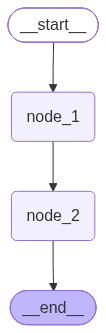

In [22]:
# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [23]:
input_data = {
    "message": "hi this is sunny"
}

for output in app.stream(input_data):
    for key, value in output.items():
        print(f"Here is output from {key}")
        print("_______")
        print(value)
        print()

Here is output from node_1
_______
{'message': 'hi this is sunnyFirst Function'}

Here is output from node_2
_______
{'message': 'hi this is sunnyFirst Functionto Second Function'}



**What is stream() in LangGraph?**

`stream()` executes a LangGraph workflow while yielding intermediate outputs as each node executes. It is useful for monitoring node-level execution and for building streaming applications. In contrast, invoke() waits for the graph execution and returns the final state."

In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [16]:
from typing import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [17]:
# LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

In [18]:
# embeddings

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2"
)

In [19]:
# LangGraph state
class State(TypedDict):
    message: str

In [ ]:

# Helper function to extract text from the response content
def _extract_text(content) -> str:
    """Handles both plain-string and list-of-blocks content shapes."""
    if isinstance(content, list):
        return "".join(
            block.get("text", "") for block in content if isinstance(block, dict)
        )
    return content

# Define the nodes
# Node 1: call the LLM
def function_1(state: State):
    response = llm.invoke(state["message"])
    return {"message": response.text}

# Node 1: uppercase the result
def function_2(state: State):
    upper_case = state["message"].upper()
    return {"message": upper_case}

In [29]:
workflow = StateGraph(State)

In [30]:
# Add nodes
workflow.add_node("llm", function_1)
workflow.add_node("upper_string", function_2)

In [31]:
# Connect nodes
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "upper_string")
workflow.add_edge("upper_string", END)


In [32]:
app_1 = workflow.compile()

In [33]:
result = app_1.invoke({
    "message": "hi this is joe wilson thamiyan!"
})

print(result)

c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'message': "HELLO JOE! IT'S GREAT TO MEET YOU. HOW CAN I HELP YOU TODAY?"}


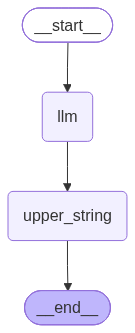

In [34]:
# Visualize graph
try:
    display(
        Image(
            app_1.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(e)

In [52]:
# LangGraph state
class State(TypedDict):
    message: str
    word_count: int

In [53]:
def function_3(state: State):
    words = state["message"].split()
    word_count = len(words)
    return {"word_count": word_count}

In [54]:
workflow_3 = StateGraph(State)

In [55]:
workflow_3.add_node("llm", function_1)
workflow_3.add_node("word_count", function_3)

In [57]:
workflow_3.add_edge(START, "llm")
workflow_3.add_edge("llm", "word_count")
workflow_3.add_edge("word_count", END)

In [58]:
app_2 = workflow_3.compile()

In [59]:
result = app_2.invoke({
    "message": "hi this is joe wilson thamiyan!",
    "word_count": 0
})

print(result)

c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'message': 'Hello Joe! Nice to meet you. How can I help you today?', 'word_count': 12}


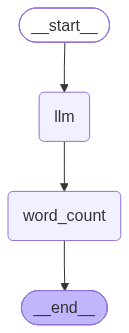

In [61]:
# Visualize graph
try:
    display(
        Image(
            app_2.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(e)